In [1]:
import pandas as pd

df = pd.read_csv('/content/amazon_vfl_reviews.csv')

print(df.head())

         asin                                     name        date  rating  \
0  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-09-06       1   
1  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-08-14       5   
2  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-10-19       1   
3  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-09-16       1   
4  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-08-18       5   

                                              review  
0  I bought this hair oil after viewing so many g...  
1  Used This Mama Earth Newly Launched Onion Oil ...  
2  So bad product...My hair falling increase too ...  
3  Product just smells similar to navarathna hair...  
4  I have been trying different onion oil for my ...  


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape: (2782, 5)

Columns:
Index(['asin', 'name', 'date', 'rating', 'review'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2782 entries, 0 to 2781
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   asin    2782 non-null   object
 1   name    2782 non-null   object
 2   date    2782 non-null   object
 3   rating  2782 non-null   int64 
 4   review  2776 non-null   object
dtypes: int64(1), object(4)
memory usage: 108.8+ KB


In [3]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
asin      0
name      0
date      0
rating    0
review    6
dtype: int64


In [4]:
print("\nRating Distribution:")
print(df['rating'].value_counts().sort_index())


Rating Distribution:
rating
1     546
2     130
3     198
4     464
5    1444
Name: count, dtype: int64


#Create Positive and Negative sentiment
For our project, we decided:

1 and 2 → Negative

3 → Remove

4 and 5 → Positive

In [5]:
# Create sentiment labels based on ratings

def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating >= 4:
        return "Positive"
    else:
        return None

df["sentiment"] = df["rating"].apply(get_sentiment)

# Remove 3-star reviews
df = df.dropna(subset=["sentiment"])

print(df.head())

         asin                                     name        date  rating  \
0  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-09-06       1   
1  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-08-14       5   
2  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-10-19       1   
3  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-09-16       1   
4  B07W7CTLD1  Mamaearth-Onion-Growth-Control-Redensyl  2019-08-18       5   

                                              review sentiment  
0  I bought this hair oil after viewing so many g...  Negative  
1  Used This Mama Earth Newly Launched Onion Oil ...  Positive  
2  So bad product...My hair falling increase too ...  Negative  
3  Product just smells similar to navarathna hair...  Negative  
4  I have been trying different onion oil for my ...  Positive  


#Check the new sentiment distribution

In [6]:
print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())


Sentiment Distribution:
sentiment
Positive    1908
Negative     676
Name: count, dtype: int64


#Check the review column

In [7]:
print(df.columns)

Index(['asin', 'name', 'date', 'rating', 'review', 'sentiment'], dtype='object')


#Check for missing reviews

In [8]:
print("\nMissing values:")
print(df["review"].isnull().sum())


Missing values:
6


#Remove the 6 missing reviews

In [9]:
# Remove rows where the review text is missing
df = df.dropna(subset=["review"])

print("Missing reviews after cleaning:")
print(df["review"].isnull().sum())

print("Dataset shape after removing missing reviews:")
print(df.shape)

Missing reviews after cleaning:
0
Dataset shape after removing missing reviews:
(2578, 6)


In [10]:
print("Duplicate reviews:")
print(df["review"].duplicated().sum())

Duplicate reviews:
1522


#Remove duplicate reviews

In [11]:
# Remove duplicate review texts
df = df.drop_duplicates(subset=["review"])

# Reset the index after removing duplicates
df = df.reset_index(drop=True)

print("Dataset shape after removing duplicates:")
print(df.shape)

print("\nDuplicate reviews after cleaning:")
print(df["review"].duplicated().sum())

Dataset shape after removing duplicates:
(1056, 6)

Duplicate reviews after cleaning:
0


#Check the sentiment distribution again

In [12]:
print("\nSentiment Distribution after cleaning:")
print(df["sentiment"].value_counts())

print("\nTotal reviews:")
print(len(df))


Sentiment Distribution after cleaning:
sentiment
Positive    767
Negative    289
Name: count, dtype: int64

Total reviews:
1056


#Text Preprocessing

In [13]:
print("Sample reviews before preprocessing:\n")

for i in range(5):
    print(f"Review {i+1}:")
    print(df.loc[i, "review"])
    print("Sentiment:", df.loc[i, "sentiment"])
    print("-" * 80)

Sample reviews before preprocessing:

Review 1:
I bought this hair oil after viewing so many good comments. But this product is not good enough.First of all it's Expensive...Second thing the amount of the product is low (half bottle) YES!The bottle is not completely filled with oil. If you cheating on your customers #Mamaearth trust me on this you can't fool people more than once. Now I know that your Brand is not good enough. I am not going to buy any product from your Brand again.Thumbs down for mamaearth onion oil !!
Sentiment: Negative
--------------------------------------------------------------------------------
Review 2:
Used This Mama Earth Newly Launched Onion Oil twice, and i must say im already impressed by the results !It prevents hair loss, helps control premature greying, dryness, dandruff, scalp eruptions and many other hair problems after its regular use !To avoid dry and frizzy hair, make sure that you use this oil to your hairs twice a week.Oiling provides your scalp

#Install/import the required NLP library

In [14]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [15]:
from nltk.corpus import stopwords
import re


#Create the preprocessing function

In [16]:
# Get English stopwords
stop_words = set(stopwords.words('english'))

# Keep important negative words
stop_words = stop_words - {'not', 'no', 'nor', 'never'}

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    # Join words back together
    return ' '.join(words)

#Apply preprocessing to your dataset

In [17]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

print(df[['review', 'cleaned_review', 'sentiment']].head())

                                              review  \
0  I bought this hair oil after viewing so many g...   
1  Used This Mama Earth Newly Launched Onion Oil ...   
2  So bad product...My hair falling increase too ...   
3  Product just smells similar to navarathna hair...   
4  I have been trying different onion oil for my ...   

                                      cleaned_review sentiment  
0  bought hair oil viewing many good comments pro...  Negative  
1  used mama earth newly launched onion oil twice...  Positive  
2  bad product hair falling increase much order s...  Negative  
3  product smells similar navarathna hair oil not...  Negative  
4  trying different onion oil hair hair not healt...  Positive  


#Compare before and after preprocessing

In [18]:
for i in range(3):
    print("ORIGINAL REVIEW:")
    print(df.loc[i, 'review'])

    print("\nCLEANED REVIEW:")
    print(df.loc[i, 'cleaned_review'])

    print("\nSENTIMENT:")
    print(df.loc[i, 'sentiment'])

    print("=" * 100)

ORIGINAL REVIEW:
I bought this hair oil after viewing so many good comments. But this product is not good enough.First of all it's Expensive...Second thing the amount of the product is low (half bottle) YES!The bottle is not completely filled with oil. If you cheating on your customers #Mamaearth trust me on this you can't fool people more than once. Now I know that your Brand is not good enough. I am not going to buy any product from your Brand again.Thumbs down for mamaearth onion oil !!

CLEANED REVIEW:
bought hair oil viewing many good comments product not good enough first expensive second thing amount product low half bottle yes bottle not completely filled oil cheating customers mamaearth trust fool people know brand not good enough not going buy product brand thumbs mamaearth onion oil

SENTIMENT:
Negative
ORIGINAL REVIEW:
Used This Mama Earth Newly Launched Onion Oil twice, and i must say im already impressed by the results !It prevents hair loss, helps control premature greyi

#Check whether any reviews became empty

In [19]:
empty_reviews = df[df['cleaned_review'].str.strip() == '']

print("Empty reviews after preprocessing:", len(empty_reviews))

Empty reviews after preprocessing: 5


#Remove the 5 empty reviews

In [20]:
# Remove reviews that became empty after preprocessing
df = df[df['cleaned_review'].str.strip() != '']

# Reset index
df = df.reset_index(drop=True)

print("Empty reviews after removal:")
print((df['cleaned_review'].str.strip() == '').sum())

print("\nFinal dataset shape:")
print(df.shape)

print("\nFinal sentiment distribution:")
print(df['sentiment'].value_counts())

Empty reviews after removal:
0

Final dataset shape:
(1051, 7)

Final sentiment distribution:
sentiment
Positive    763
Negative    288
Name: count, dtype: int64


Check that there are no missing values

In [21]:
print("\nMissing values:")
print(df[['review', 'cleaned_review', 'sentiment']].isnull().sum())


Missing values:
review            0
cleaned_review    0
sentiment         0
dtype: int64


Save the cleaned dataset

In [22]:
df.to_csv('/content/cleaned_product_reviews.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


#**Train/Test Split and TF-IDF**
We need to divide the data into:

Training data → 80%
Testing data → 20%

With 1,051 reviews, this will be approximately:

Training: 841 reviews
Testing: 210 reviews

The model learns from the training reviews and is evaluated on the unseen testing reviews.

**Select X and y**

Here:

X = review text

y = sentiment

In [23]:
# Select input and target variables

X = df['cleaned_review']
y = df['sentiment']

print("Number of reviews:", len(X))
print("Number of labels:", len(y))

Number of reviews: 1051
Number of labels: 1051


**Split the dataset**

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 840
Testing reviews: 211


**Check the training and testing sentiment distribution**

In [25]:
print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())


Training sentiment distribution:
sentiment
Positive    610
Negative    230
Name: count, dtype: int64

Testing sentiment distribution:
sentiment
Positive    153
Negative     58
Name: count, dtype: int64


**Now apply TF-IDF**

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (840, 5000)
Testing TF-IDF shape: (211, 5000)


**See the TF-IDF features**

In [27]:
features = tfidf.get_feature_names_out()

print("Number of features:", len(features))
print("\nFirst 30 features:")
print(features[:30])

Number of features: 5000

First 30 features:
['aa' 'aa rha' 'aamras' 'aamras around' 'aamras feel' 'aamras juice'
 'abandon' 'abandon old' 'abck' 'abck normal' 'able' 'able breath'
 'able get' 'able go' 'able hope' 'able situation' 'abroad' 'absolutely'
 'absorbed' 'absorbed air' 'access' 'according' 'account' 'accurate'
 'acne' 'acne pimple' 'acne prone' 'across' 'action' 'actual']


#**Train the Machine Learning Model**

For your project, we will use:

Logistic Regression

**Train the model**

In [28]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


**Predict sentiments**

In [29]:
y_pred = model.predict(X_test_tfidf)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
['Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive']


#**Evaluate the Model**

Now calculate:

Accuracy
Precision
Recall
F1-score

In [30]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8530805687203792

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.48      0.64        58
    Positive       0.84      0.99      0.91       153

    accuracy                           0.85       211
   macro avg       0.90      0.74      0.78       211
weighted avg       0.87      0.85      0.83       211



#**Confusion Matrix**

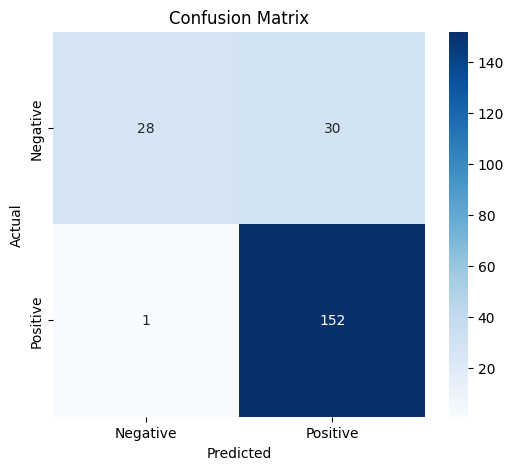

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(model, '/content/sentiment_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(tfidf, '/content/tfidf_vectorizer.pkl')

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!
